# Compare Training Runs With The ACDC Paper

This notebook loads every experiment in `runs/`, summarizes training behavior, and compares the best validation Dice values with the results reported in *An Exploration of 2D and 3D Deep Learning Techniques for Cardiac MR Image Segmentation*.

Important comparison note: the local training logs report slice-level validation metrics from the project split. The paper reports volume-level challenge metrics at end-diastole (ED) and end-systole (ES), including postprocessing and surface-distance measures. The Dice comparisons below are therefore useful for orientation, not a strict reproduction claim.


In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.precision", 4)

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

RUNS_ROOT = PROJECT_ROOT / "runs"
PAPER_PATH = PROJECT_ROOT / "papers" / "An-Exploration-of-2D-and-3D-Deep-Learning.pdf"

print(f"Project root: {PROJECT_ROOT}")
print(f"Runs root: {RUNS_ROOT}")
print(f"Paper: {PAPER_PATH.relative_to(PROJECT_ROOT) if PAPER_PATH.exists() else 'not found'}")


Project root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge
Runs root: /home/basic/Faks/Automated-Cardiac-Diagnosis-Challenge/runs
Paper: papers/An-Exploration-of-2D-and-3D-Deep-Learning.pdf


## Load Local Experiment Logs

In [2]:
CLASS_NAMES = {
    "0": "Background",
    "1": "RV",
    "2": "Myo",
    "3": "LV",
}

MODEL_NAME_RULES = [
    ("fcn8", "FCN-8"),
    ("unet2d_modified", "2D U-Net (mod.)"),
    ("unet2d", "2D U-Net"),
    ("unet3d", "3D U-Net (mod.)"),
]


def infer_model_name(run_name):
    for token, model_name in MODEL_NAME_RULES:
        if run_name.startswith(token):
            return model_name
    return run_name


def load_config(config_path):
    if not config_path.exists():
        return {}
    return json.loads(config_path.read_text())


def load_runs(runs_root):
    frames = []
    configs = {}
    for metrics_path in sorted(runs_root.glob("*/metrics.csv")):
        run_dir = metrics_path.parent
        run_name = run_dir.name
        metrics = pd.read_csv(metrics_path)
        metrics["run"] = run_name
        metrics["model"] = infer_model_name(run_name)
        frames.append(metrics)
        configs[run_name] = load_config(run_dir / "config.json")

    if not frames:
        raise RuntimeError(f"No metrics.csv files found under {runs_root}")

    return pd.concat(frames, ignore_index=True), configs


metrics, configs = load_runs(RUNS_ROOT)
print(f"Loaded {metrics['run'].nunique()} runs and {len(metrics)} epoch rows.")
display(metrics.head())


Loaded 10 runs and 1015 epoch rows.


,epoch,train_loss,train_pixel_accuracy,train_mean_foreground_dice,val_loss,val_pixel_accuracy,val_mean_foreground_dice,learning_rate,epoch_seconds,elapsed_seconds,elapsed_time,train_dice_class_0,train_dice_class_1,train_dice_class_2,train_dice_class_3,val_dice_class_0,val_dice_class_1,val_dice_class_2,val_dice_class_3,run,model
0,1,24.3209,0.9102,0.0590,6.9007,0.9528,0.1208,0.001,47.6994,48.8294,00:00:49,0.9555,0.0523,0.0569,0.0679,0.9780,0.0000,0.0369,0.3255,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8
1,2,1.3816,0.9429,0.1618,0.1887,0.9544,0.2969,0.001,48.3757,98.4474,00:01:38,0.9750,0.1462,0.1178,0.2214,0.9819,0.2699,0.1472,0.4736,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8
2,3,0.2046,0.9605,0.2765,0.1297,0.9588,0.3944,0.001,48.1645,147.7958,00:02:28,0.9836,0.2390,0.1883,0.4022,0.9838,0.3290,0.2806,0.5736,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8
3,4,0.1375,0.9663,0.3847,0.1167,0.9614,0.4714,0.001,47.9570,196.8223,00:03:17,0.9863,0.3581,0.2719,0.5242,0.9844,0.4290,0.3398,0.6454,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8
4,5,0.1549,0.9656,0.3830,0.4730,0.9519,0.0266,0.001,48.2751,246.1892,00:04:06,0.9862,0.3451,0.2945,0.5095,0.9758,0.0402,0.0144,0.0252,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8


## Run Configuration Overview

In [3]:
def config_value(config, key, default=None):
    return config.get("args", {}).get(key, config.get(key, default))

config_rows = []
for run, config in configs.items():
    config_rows.append({
        "run": run,
        "model": infer_model_name(run),
        "epochs_configured": config_value(config, "epochs"),
        "batch_size": config_value(config, "batch_size"),
        "learning_rate": config_value(config, "learning_rate"),
        "loss": config_value(config, "loss", "cross_entropy"),
        "device": config.get("device"),
        "train_files": config.get("num_train_files"),
        "val_files": config.get("num_val_files"),
        "combined_run": "combined_from" in config,
        "weights": config_value(config, "weights"),
    })

config_summary = pd.DataFrame(config_rows).sort_values(["model", "run"])
display(config_summary)


,run,model,epochs_configured,batch_size,learning_rate,loss,device,train_files,val_files,combined_run,weights
5,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,200,4,0.0001,cross_entropy,cuda,1538,374,False,NaN
6,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),100,8,0.0100,dice,cuda,1538,374,False,NaN
7,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),100,8,0.0100,weighted_cross_entropy,cuda,1538,374,False,NaN
8,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),200,4,0.0001,cross_entropy,cuda,1538,374,False,NaN
9,unet3d,3D U-Net (mod.),100,1,0.0100,cross_entropy,cuda,160,40,False,NaN
0,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,100,16,0.0010,cross_entropy,cuda,1538,374,False,NaN
1,fcn8_150epoch_combined_from_100_plus_50,FCN-8,150,16,0.0010,cross_entropy,cuda,1538,374,True,runs\fcn8_100epoch_gpu_bs16_lr1e-3\latest_epoc...
2,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,5,16,0.0010,cross_entropy,cuda,1538,374,False,NaN
3,fcn8_5epoch_local,FCN-8,5,8,0.0100,cross_entropy,cuda,1538,374,False,NaN
4,fcn8_continue_50epoch_from_epoch100,FCN-8,50,16,0.0010,cross_entropy,cuda,1538,374,False,runs\fcn8_100epoch_gpu_bs16_lr1e-3\latest_epoc...


## Best Epoch Summary

In [4]:
best_indices = metrics.groupby("run")["val_mean_foreground_dice"].idxmax()
best_rows = metrics.loc[best_indices].copy().set_index("run")
last_rows = metrics.sort_values("epoch").groupby("run", as_index=False).tail(1).set_index("run")

summary_rows = []
for run, best in best_rows.iterrows():
    last = last_rows.loc[run]
    config = configs.get(run, {})
    summary_rows.append({
        "run": run,
        "model": best["model"],
        "logged_epochs": int(metrics.loc[metrics["run"] == run, "epoch"].max()),
        "best_epoch": int(best["epoch"]),
        "best_val_mean_fg_dice": best["val_mean_foreground_dice"],
        "final_val_mean_fg_dice": last["val_mean_foreground_dice"],
        "best_val_loss": best["val_loss"],
        "best_val_pixel_accuracy": best["val_pixel_accuracy"],
        "best_val_RV_dice": best.get("val_dice_class_1", math.nan),
        "best_val_Myo_dice": best.get("val_dice_class_2", math.nan),
        "best_val_LV_dice": best.get("val_dice_class_3", math.nan),
        "loss": config_value(config, "loss", "cross_entropy"),
        "learning_rate": config_value(config, "learning_rate"),
        "batch_size": config_value(config, "batch_size"),
    })

run_summary = pd.DataFrame(summary_rows).sort_values("best_val_mean_fg_dice", ascending=False).reset_index(drop=True)
display(run_summary.style.format({
    "best_val_mean_fg_dice": "{:.3f}",
    "final_val_mean_fg_dice": "{:.3f}",
    "best_val_loss": "{:.4f}",
    "best_val_pixel_accuracy": "{:.3f}",
    "best_val_RV_dice": "{:.3f}",
    "best_val_Myo_dice": "{:.3f}",
    "best_val_LV_dice": "{:.3f}",
    "learning_rate": "{:.1e}",
}))


,run,model,logged_epochs,best_epoch,best_val_mean_fg_dice,final_val_mean_fg_dice,best_val_loss,best_val_pixel_accuracy,best_val_RV_dice,best_val_Myo_dice,best_val_LV_dice,loss,learning_rate,batch_size
0,unet3d,3D U-Net (mod.),100,97,0.874,0.793,0.0039,0.999,0.865,0.822,0.936,cross_entropy,1.0e-02,1
1,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),100,66,0.842,0.833,0.2360,0.988,0.827,0.790,0.911,weighted_cross_entropy,1.0e-02,8
2,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),200,64,0.839,0.825,0.1086,0.987,0.845,0.778,0.895,cross_entropy,1.0e-04,4
3,fcn8_150epoch_combined_from_100_plus_50,FCN-8,150,104,0.828,0.734,0.0666,0.987,0.806,0.754,0.925,cross_entropy,1.0e-03,16
4,fcn8_continue_50epoch_from_epoch100,FCN-8,50,4,0.828,0.734,0.0666,0.987,0.806,0.754,0.925,cross_entropy,1.0e-03,16
5,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,200,30,0.826,0.816,0.0901,0.986,0.819,0.770,0.888,cross_entropy,1.0e-04,4
6,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,100,100,0.818,0.818,0.0832,0.986,0.809,0.745,0.901,cross_entropy,1.0e-03,16
7,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),100,72,0.794,0.790,0.2408,0.984,0.739,0.747,0.895,dice,1.0e-02,8
8,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,5,5,0.427,0.224,0.1194,0.963,0.358,0.303,0.619,cross_entropy,1.0e-03,16
9,fcn8_5epoch_local,FCN-8,5,5,0.318,0.318,0.4119,0.957,0.253,0.205,0.497,cross_entropy,1.0e-02,8


## Training Curves

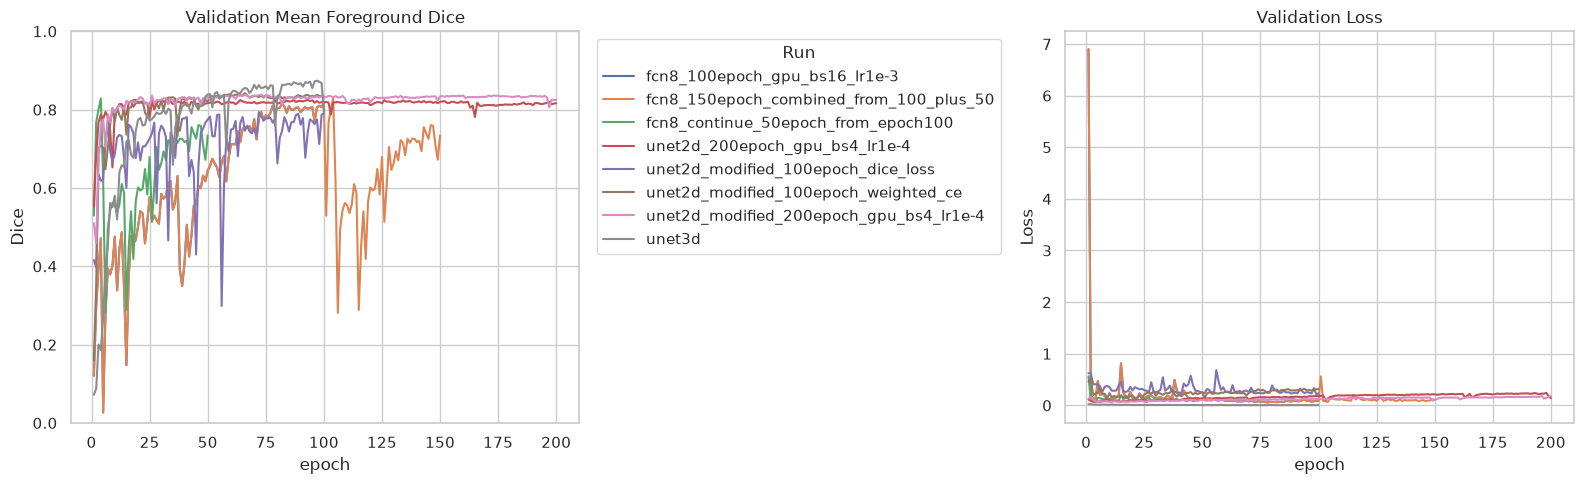

In [5]:
curve_runs = run_summary.loc[~run_summary["run"].str.contains("5epoch", case=False), "run"].tolist()
curve_data = metrics[metrics["run"].isin(curve_runs)].copy()

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=False)

sns.lineplot(data=curve_data, x="epoch", y="val_mean_foreground_dice", hue="run", ax=axes[0])
axes[0].set_title("Validation Mean Foreground Dice")
axes[0].set_ylabel("Dice")
axes[0].set_ylim(0, 1)
axes[0].legend(title="Run", bbox_to_anchor=(1.02, 1), loc="upper left")

sns.lineplot(data=curve_data, x="epoch", y="val_loss", hue="run", ax=axes[1], legend=False)
axes[1].set_title("Validation Loss")
axes[1].set_ylabel("Loss")

plt.tight_layout()


## Per-Class Best Validation Dice

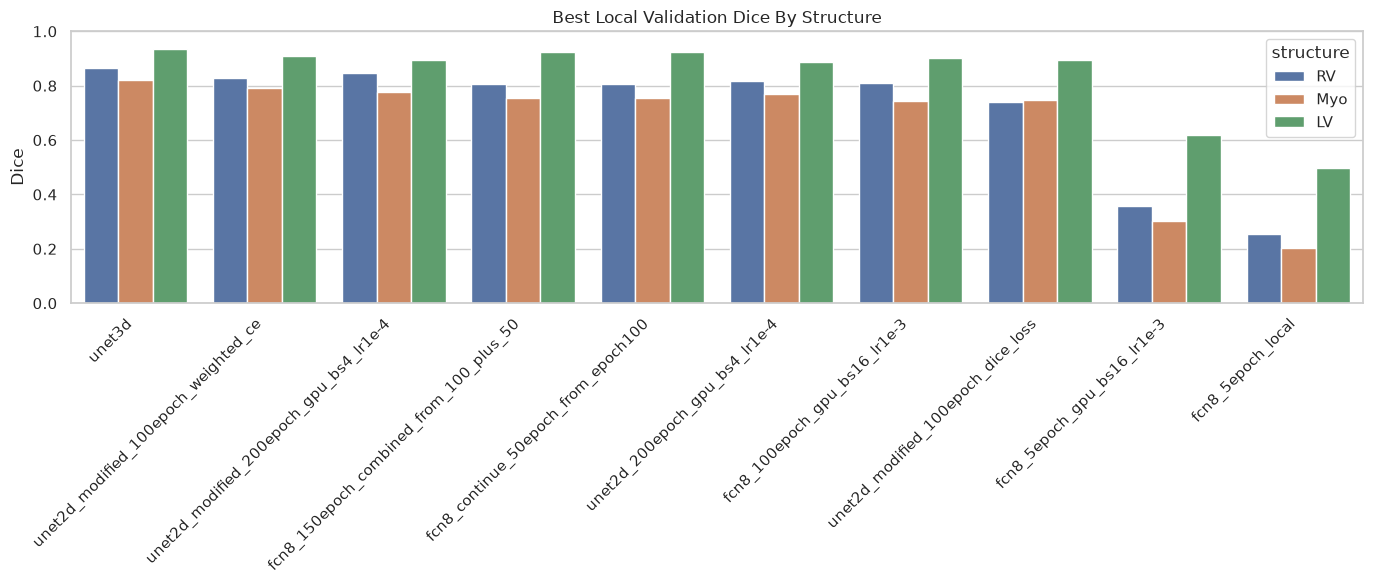

In [6]:
per_class_cols = ["best_val_RV_dice", "best_val_Myo_dice", "best_val_LV_dice"]
per_class = run_summary[["run", "model", *per_class_cols]].melt(
    id_vars=["run", "model"],
    var_name="structure",
    value_name="dice",
)
per_class["structure"] = per_class["structure"].map({
    "best_val_RV_dice": "RV",
    "best_val_Myo_dice": "Myo",
    "best_val_LV_dice": "LV",
})

plt.figure(figsize=(14, 6))
sns.barplot(data=per_class, x="run", y="dice", hue="structure")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1)
plt.title("Best Local Validation Dice By Structure")
plt.ylabel("Dice")
plt.xlabel("")
plt.tight_layout()


## Paper Reference Values

The values below are transcribed from the paper tables. Table 1 reports modified 2D U-Net loss-function results averaged over both cardiac phases. Table 2 reports architecture results by structure and phase.


In [7]:
paper_loss = pd.DataFrame([
    {"model": "2D U-Net (mod.)", "loss": "cross_entropy", "structure": "LV", "paper_dice": 0.950, "paper_std": 0.029},
    {"model": "2D U-Net (mod.)", "loss": "cross_entropy", "structure": "RV", "paper_dice": 0.891, "paper_std": 0.084},
    {"model": "2D U-Net (mod.)", "loss": "cross_entropy", "structure": "Myo", "paper_dice": 0.888, "paper_std": 0.031},
    {"model": "2D U-Net (mod.)", "loss": "weighted_cross_entropy", "structure": "LV", "paper_dice": 0.950, "paper_std": 0.036},
    {"model": "2D U-Net (mod.)", "loss": "weighted_cross_entropy", "structure": "RV", "paper_dice": 0.893, "paper_std": 0.083},
    {"model": "2D U-Net (mod.)", "loss": "weighted_cross_entropy", "structure": "Myo", "paper_dice": 0.899, "paper_std": 0.032},
    {"model": "2D U-Net (mod.)", "loss": "dice", "structure": "LV", "paper_dice": 0.944, "paper_std": 0.051},
    {"model": "2D U-Net (mod.)", "loss": "dice", "structure": "RV", "paper_dice": 0.843, "paper_std": 0.137},
    {"model": "2D U-Net (mod.)", "loss": "dice", "structure": "Myo", "paper_dice": 0.891, "paper_std": 0.029},
])

architecture_values = {
    "FCN-8": {
        "LV": {"ED": (0.960, 0.018), "ES": (0.926, 0.061)},
        "RV": {"ED": (0.932, 0.025), "ES": (0.835, 0.100)},
        "Myo": {"ED": (0.869, 0.029), "ES": (0.890, 0.027)},
    },
    "2D U-Net": {
        "LV": {"ED": (0.965, 0.014), "ES": (0.937, 0.051)},
        "RV": {"ED": (0.936, 0.028), "ES": (0.838, 0.085)},
        "Myo": {"ED": (0.885, 0.027), "ES": (0.904, 0.029)},
    },
    "2D U-Net (mod.)": {
        "LV": {"ED": (0.966, 0.017), "ES": (0.935, 0.042)},
        "RV": {"ED": (0.934, 0.039), "ES": (0.852, 0.095)},
        "Myo": {"ED": (0.892, 0.027), "ES": (0.906, 0.034)},
    },
    "3D U-Net (mod.)": {
        "LV": {"ED": (0.939, 0.022), "ES": (0.905, 0.039)},
        "RV": {"ED": (0.888, 0.069), "ES": (0.781, 0.101)},
        "Myo": {"ED": (0.802, 0.053), "ES": (0.839, 0.066)},
    },
}

paper_arch_rows = []
for model, structures in architecture_values.items():
    for structure, phases in structures.items():
        for phase, (dice, std) in phases.items():
            paper_arch_rows.append({
                "model": model,
                "structure": structure,
                "phase": phase,
                "paper_dice": dice,
                "paper_std": std,
            })

paper_arch = pd.DataFrame(paper_arch_rows)
paper_arch_avg = paper_arch.groupby(["model", "structure"], as_index=False).agg(
    paper_phase_avg_dice=("paper_dice", "mean"),
    paper_phase_avg_std=("paper_std", "mean"),
)
paper_arch_model_avg = paper_arch_avg.groupby("model", as_index=False).agg(
    paper_mean_fg_dice=("paper_phase_avg_dice", "mean"),
)

print("Paper Table 1: loss function Dice")
display(paper_loss)
print("Paper Table 2: architecture Dice averaged over ED and ES")
display(paper_arch_avg)
print("Paper Table 2: mean over LV/RV/Myo after phase averaging")
display(paper_arch_model_avg.sort_values("paper_mean_fg_dice", ascending=False))


Paper Table 1: loss function Dice


,model,loss,structure,paper_dice,paper_std
0,2D U-Net (mod.),cross_entropy,LV,0.950,0.029
1,2D U-Net (mod.),cross_entropy,RV,0.891,0.084
2,2D U-Net (mod.),cross_entropy,Myo,0.888,0.031
3,2D U-Net (mod.),weighted_cross_entropy,LV,0.950,0.036
4,2D U-Net (mod.),weighted_cross_entropy,RV,0.893,0.083
5,2D U-Net (mod.),weighted_cross_entropy,Myo,0.899,0.032
6,2D U-Net (mod.),dice,LV,0.944,0.051
7,2D U-Net (mod.),dice,RV,0.843,0.137
8,2D U-Net (mod.),dice,Myo,0.891,0.029


Paper Table 2: architecture Dice averaged over ED and ES


,model,structure,paper_phase_avg_dice,paper_phase_avg_std
0,2D U-Net,LV,0.9510,0.0325
1,2D U-Net,Myo,0.8945,0.0280
2,2D U-Net,RV,0.8870,0.0565
3,2D U-Net (mod.),LV,0.9505,0.0295
4,2D U-Net (mod.),Myo,0.8990,0.0305
5,2D U-Net (mod.),RV,0.8930,0.0670
6,3D U-Net (mod.),LV,0.9220,0.0305
7,3D U-Net (mod.),Myo,0.8205,0.0595
8,3D U-Net (mod.),RV,0.8345,0.0850
9,FCN-8,LV,0.9430,0.0395


Paper Table 2: mean over LV/RV/Myo after phase averaging


,model,paper_mean_fg_dice
1,2D U-Net (mod.),0.9142
0,2D U-Net,0.9108
3,FCN-8,0.9020
2,3D U-Net (mod.),0.8590


## Local Runs Versus Paper Architecture Results

,run,model,structure,local_dice,paper_phase_avg_dice,paper_phase_avg_std,delta_vs_paper_phase_avg
25,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,LV,0.888,0.951,0.033,-0.063
15,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,Myo,0.770,0.895,0.028,-0.125
5,unet2d_200epoch_gpu_bs4_lr1e-4,2D U-Net,RV,0.819,0.887,0.057,-0.068
27,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),LV,0.895,0.951,0.030,-0.056
17,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),Myo,0.747,0.899,0.030,-0.152
7,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),RV,0.739,0.893,0.067,-0.154
21,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),LV,0.911,0.951,0.030,-0.040
11,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),Myo,0.790,0.899,0.030,-0.109
1,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),RV,0.827,0.893,0.067,-0.066
22,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),LV,0.895,0.951,0.030,-0.055


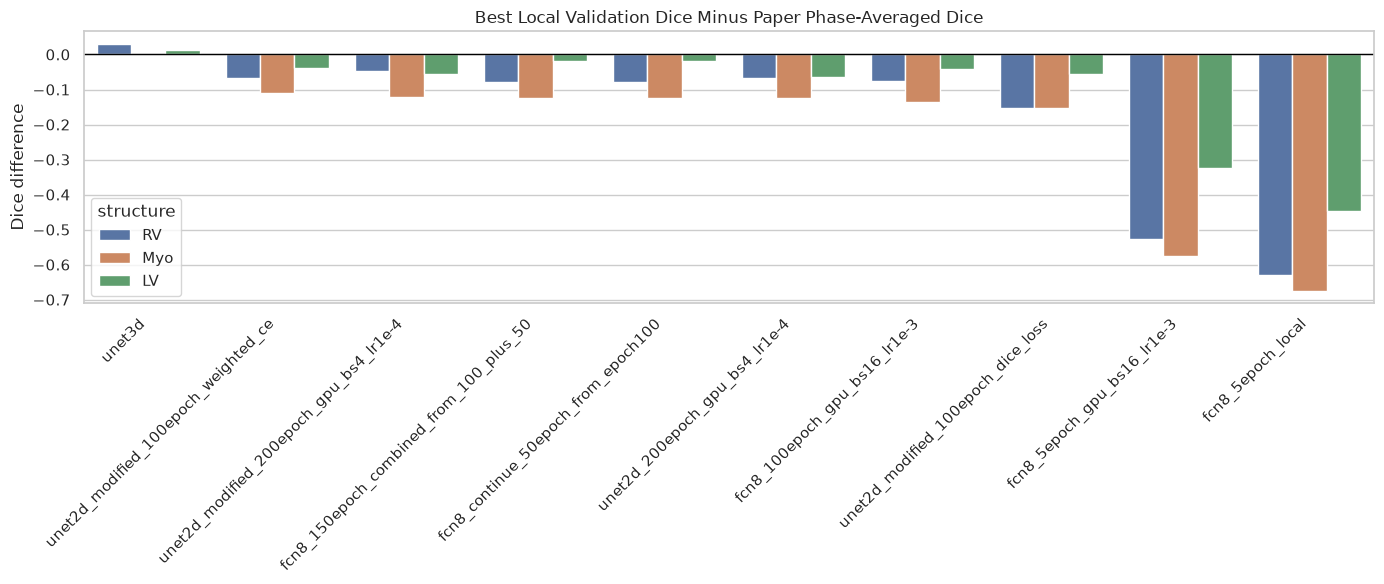

In [8]:
local_structure = per_class.rename(columns={"dice": "local_dice"}).copy()
comparison = local_structure.merge(paper_arch_avg, on=["model", "structure"], how="left")
comparison["delta_vs_paper_phase_avg"] = comparison["local_dice"] - comparison["paper_phase_avg_dice"]

comparison_table = comparison.sort_values(["model", "run", "structure"])
display(comparison_table.style.format({
    "local_dice": "{:.3f}",
    "paper_phase_avg_dice": "{:.3f}",
    "paper_phase_avg_std": "{:.3f}",
    "delta_vs_paper_phase_avg": "{:+.3f}",
}))

plt.figure(figsize=(14, 6))
plot_data = comparison.dropna(subset=["paper_phase_avg_dice"]).copy()
sns.barplot(data=plot_data, x="run", y="delta_vs_paper_phase_avg", hue="structure")
plt.axhline(0, color="black", linewidth=1)
plt.xticks(rotation=45, ha="right")
plt.title("Best Local Validation Dice Minus Paper Phase-Averaged Dice")
plt.ylabel("Dice difference")
plt.xlabel("")
plt.tight_layout()


## Best Local Model Compared With Paper Ranking

,model,run,best_epoch,best_val_mean_fg_dice,paper_mean_fg_dice,delta_vs_paper_mean_fg,loss,learning_rate,batch_size
0,3D U-Net (mod.),unet3d,97,0.874,0.859,+0.015,cross_entropy,1.0e-02,1
1,2D U-Net (mod.),unet2d_modified_100epoch_weighted_ce,66,0.842,0.914,-0.072,weighted_cross_entropy,1.0e-02,8
2,FCN-8,fcn8_150epoch_combined_from_100_plus_50,104,0.828,0.902,-0.074,cross_entropy,1.0e-03,16
3,2D U-Net,unet2d_200epoch_gpu_bs4_lr1e-4,30,0.826,0.911,-0.085,cross_entropy,1.0e-04,4


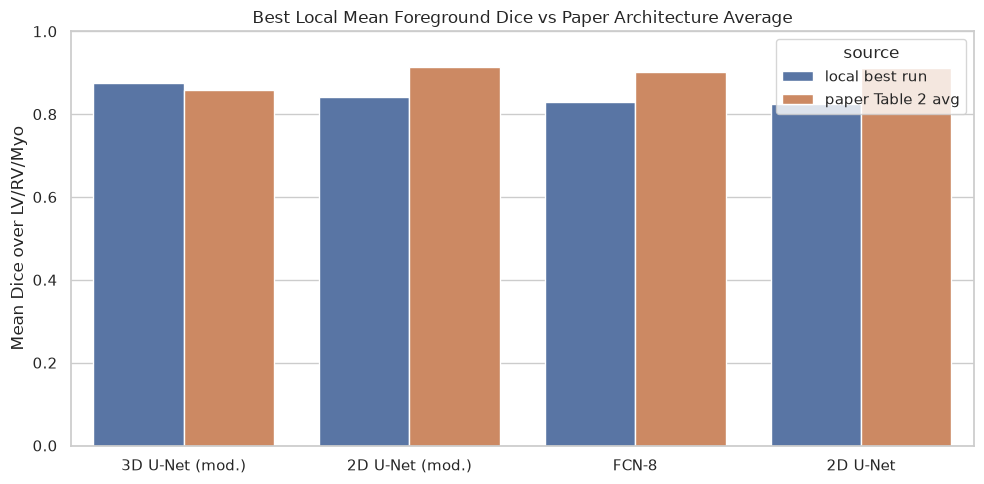

In [9]:
best_per_model = run_summary.sort_values("best_val_mean_fg_dice", ascending=False).groupby("model", as_index=False).head(1)
model_comparison = best_per_model.merge(paper_arch_model_avg, on="model", how="left")
model_comparison["delta_vs_paper_mean_fg"] = model_comparison["best_val_mean_fg_dice"] - model_comparison["paper_mean_fg_dice"]
model_comparison = model_comparison.sort_values("best_val_mean_fg_dice", ascending=False)

display(model_comparison[[
    "model",
    "run",
    "best_epoch",
    "best_val_mean_fg_dice",
    "paper_mean_fg_dice",
    "delta_vs_paper_mean_fg",
    "loss",
    "learning_rate",
    "batch_size",
]].style.format({
    "best_val_mean_fg_dice": "{:.3f}",
    "paper_mean_fg_dice": "{:.3f}",
    "delta_vs_paper_mean_fg": "{:+.3f}",
    "learning_rate": "{:.1e}",
}))

combined = pd.concat([
    model_comparison[["model", "best_val_mean_fg_dice"]].rename(columns={"best_val_mean_fg_dice": "dice"}).assign(source="local best run"),
    paper_arch_model_avg.rename(columns={"paper_mean_fg_dice": "dice"}).assign(source="paper Table 2 avg"),
], ignore_index=True)

plt.figure(figsize=(10, 5))
sns.barplot(data=combined.dropna(subset=["dice"]), x="model", y="dice", hue="source")
plt.ylim(0, 1)
plt.title("Best Local Mean Foreground Dice vs Paper Architecture Average")
plt.ylabel("Mean Dice over LV/RV/Myo")
plt.xlabel("")
plt.tight_layout()


## Modified U-Net Loss Comparison

In [10]:
local_loss_runs = run_summary[run_summary["model"] == "2D U-Net (mod.)"].copy()
local_loss_structure = per_class[per_class["run"].isin(local_loss_runs["run"])].merge(
    local_loss_runs[["run", "loss"]], on="run", how="left"
).rename(columns={"dice": "local_dice"})

loss_comparison = local_loss_structure.merge(
    paper_loss,
    on=["model", "loss", "structure"],
    how="left",
)
loss_comparison["delta_vs_paper_loss_table"] = loss_comparison["local_dice"] - loss_comparison["paper_dice"]

display(loss_comparison.sort_values(["loss", "run", "structure"]).style.format({
    "local_dice": "{:.3f}",
    "paper_dice": "{:.3f}",
    "paper_std": "{:.3f}",
    "delta_vs_paper_loss_table": "{:+.3f}",
}))


,run,model,structure,local_dice,loss,paper_dice,paper_std,delta_vs_paper_loss_table
7,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),LV,0.895,cross_entropy,0.950,0.029,-0.055
4,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),Myo,0.778,cross_entropy,0.888,0.031,-0.110
1,unet2d_modified_200epoch_gpu_bs4_lr1e-4,2D U-Net (mod.),RV,0.845,cross_entropy,0.891,0.084,-0.046
8,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),LV,0.895,dice,0.944,0.051,-0.049
5,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),Myo,0.747,dice,0.891,0.029,-0.144
2,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),RV,0.739,dice,0.843,0.137,-0.104
6,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),LV,0.911,weighted_cross_entropy,0.950,0.036,-0.039
3,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),Myo,0.790,weighted_cross_entropy,0.899,0.032,-0.109
0,unet2d_modified_100epoch_weighted_ce,2D U-Net (mod.),RV,0.827,weighted_cross_entropy,0.893,0.083,-0.066


## Observations Template

Run the notebook, then use the tables above to fill in these notes:

- Best local run by validation mean foreground Dice: see `run_summary.iloc[0]`.
- Strongest local structure: compare RV/Myo/LV bars in the per-class plot.
- Biggest gap to the paper: sort `comparison_table` by `delta_vs_paper_phase_avg`.
- Most important caveat: local values are validation-slice Dice, while paper values are ED/ES volume-level challenge metrics with ASSD/HD, so exact parity is not expected.


In [11]:
print("Best local run:")
display(run_summary.iloc[[0]])

print("Largest local shortfalls against paper phase-averaged Dice:")
display(
    comparison_table.dropna(subset=["delta_vs_paper_phase_avg"])
    .sort_values("delta_vs_paper_phase_avg")
    .head(10)
    [["run", "model", "structure", "local_dice", "paper_phase_avg_dice", "delta_vs_paper_phase_avg"]]
)


Best local run:


,run,model,logged_epochs,best_epoch,best_val_mean_fg_dice,final_val_mean_fg_dice,best_val_loss,best_val_pixel_accuracy,best_val_RV_dice,best_val_Myo_dice,best_val_LV_dice,loss,learning_rate,batch_size
0,unet3d,3D U-Net (mod.),100,97,0.8742,0.7933,0.0039,0.9988,0.8653,0.8216,0.9358,cross_entropy,0.01,1


Largest local shortfalls against paper phase-averaged Dice:


,run,model,structure,local_dice,paper_phase_avg_dice,delta_vs_paper_phase_avg
19,fcn8_5epoch_local,FCN-8,Myo,0.2046,0.8795,-0.6749
9,fcn8_5epoch_local,FCN-8,RV,0.2528,0.8835,-0.6307
18,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,Myo,0.3034,0.8795,-0.5761
8,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,RV,0.3578,0.8835,-0.5257
29,fcn8_5epoch_local,FCN-8,LV,0.4971,0.9430,-0.4459
28,fcn8_5epoch_gpu_bs16_lr1e-3,FCN-8,LV,0.6186,0.9430,-0.3244
7,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),RV,0.7389,0.8930,-0.1541
17,unet2d_modified_100epoch_dice_loss,2D U-Net (mod.),Myo,0.7474,0.8990,-0.1516
16,fcn8_100epoch_gpu_bs16_lr1e-3,FCN-8,Myo,0.7450,0.8795,-0.1345
13,fcn8_150epoch_combined_from_100_plus_50,FCN-8,Myo,0.7544,0.8795,-0.1251
